In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
df = pd.read_csv('breast_cancer_data.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.drop(["id", "Unnamed: 32"], axis=1, inplace=True)

In [5]:
df["diagnosis"].replace({"B": 0, "M": 1}, inplace=True)

In [6]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<AxesSubplot:>

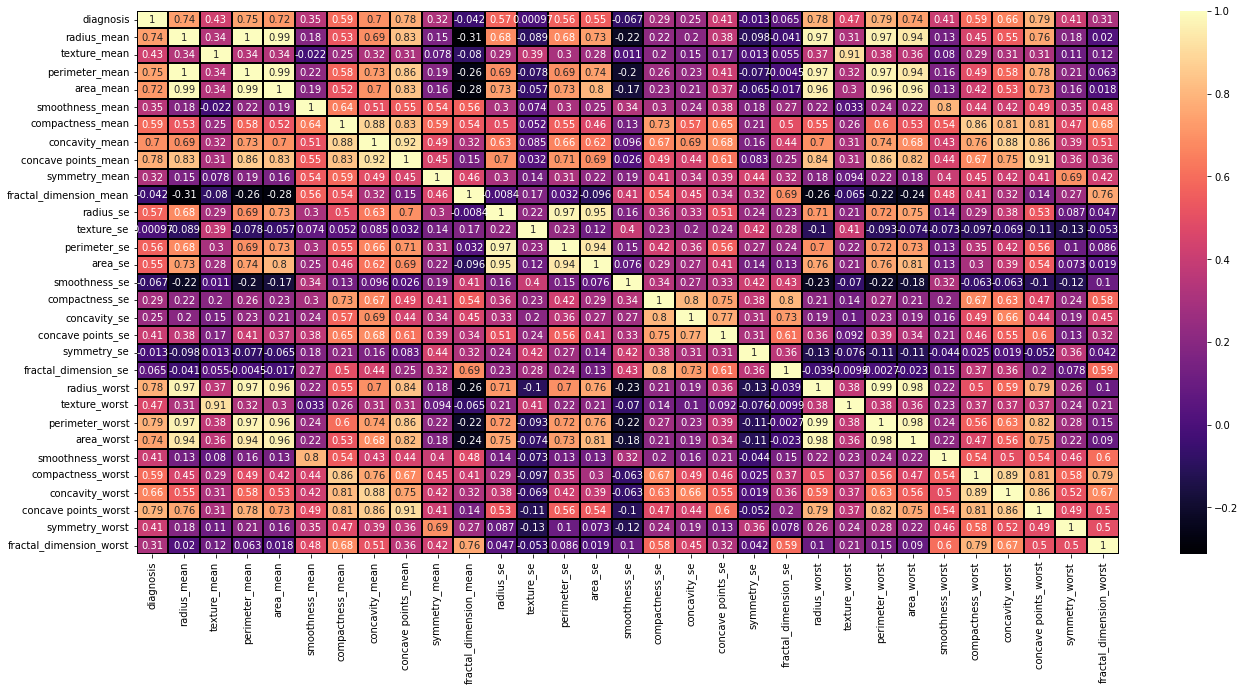

In [7]:
import seaborn as sns
plt.figure(figsize=(22,10))
sns.heatmap(df.iloc[11:,0:31].corr(), annot=True, cmap='magma',linewidths=2,linecolor='black')
#plt.savefig('BR_CORR_ff.jpg', format='jpg', dpi=1000) 
#cmap='magma',linewidths=2,linecolor='black

In [7]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"].replace({"B": 0, "M": 1})

In [9]:
df.iloc[:,1:12].corr()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,0.679090
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,0.275869
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,0.691765
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,0.732562
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,0.301467
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,0.497473
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,0.631925
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,0.698050
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,0.303379
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,0.000111


<AxesSubplot:>

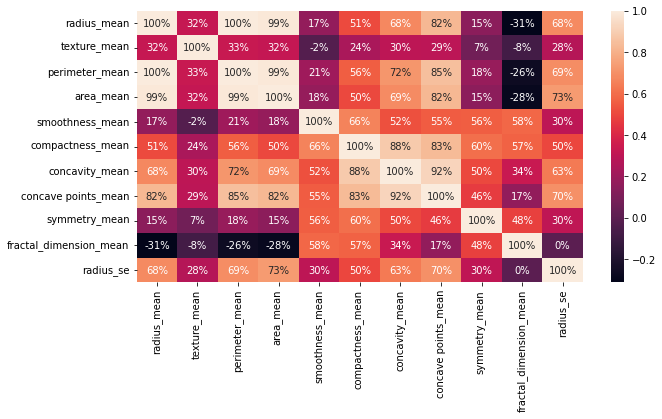

In [8]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.heatmap(df.iloc[:,1:12].corr(), annot=True, fmt=".0%")

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

tree = DecisionTreeClassifier(criterion='entropy')
tree.fit(X_train, y_train)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=10, criterion='entropy')
rf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10)

In [12]:
acc_knn = knn.score(X_test,y_test)
acc_tree = tree.score(X_test, y_test)
acc_lg = log_reg.score(X_test, y_test)
acc_rf = rf.score(X_test, y_test)

print("K-Nearest Neighbours Accuracy:", acc_knn)
print("DecisionTreeClassifier Accuracy:", acc_tree)
print("LogisticRegression Accuracy:", acc_lg)
print("RandomForestClassifier Accuracy:", acc_rf)

K-Nearest Neighbours Accuracy: 0.9649122807017544
DecisionTreeClassifier Accuracy: 0.9239766081871345
LogisticRegression Accuracy: 0.9766081871345029
RandomForestClassifier Accuracy: 0.9649122807017544


In [13]:
pred_prob = knn.predict_proba(X_test)
fpr, tpr, thresh = roc_curve(y_test, pred_prob[:,1], pos_label=1)
score = roc_auc_score(y_test, pred_prob[:, 1])

pred_prob_tree = tree.predict_proba(X_test)
fpr_tree, tpr_tree, thresh_tree = roc_curve(y_test, pred_prob_tree[:,1], pos_label=1)
score_tree = roc_auc_score(y_test, pred_prob_tree[:, 1])

pred_prob_rf = rf.predict_proba(X_test)
fpr_rf, tpr_rf, thresh_rf = roc_curve(y_test, pred_prob_rf[:,1], pos_label=1)
score_rf = roc_auc_score(y_test, pred_prob_rf[:, 1])

pred_prob_lg = log_reg.predict_proba(X_test)
fpr_lg, tpr_lg, thresh_lg = roc_curve(y_test, pred_prob_lg[:,1], pos_label=1)
score_lg = roc_auc_score(y_test, pred_prob_lg[:, 1])

# fig, ax = plt.subplots(2,2, figsize=(22,7))
# ax[0].plot(fpr, tpr, linestyle="--", color="orange", label="ROC curve (area = %0.5f)" % score)
# ax[0].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
# ax[0].set_title("KNN ROC Curve", size=15)
# ax[0].set_xlabel("False Positive Rate")
# ax[0].set_ylabel("True Positive Rate")
# ax[0].legend(loc="lower right", prop={'size': 12})

# ax[1].plot(fpr_tree, tpr_tree, linestyle="--", color="red", label="ROC curve (area = %0.5f)" % score_tree)
# ax[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
# ax[1].set_title("Decision Tree ROC Curve", size=15)
# ax[1].set_xlabel("False Positive Rate")
# ax[1].set_ylabel("True Positive Rate")
# ax[1].legend(loc="lower right", prop={'size': 12})

# ax[2].plot(fpr_rf, tpr_rf, linestyle="--", color="yellow", label="ROC curve (area = %0.5f)" % score_rf)
# ax[2].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
# ax[2].set_title("Random Forest ROC Curve", size=15)
# ax[2].set_xlabel("False Positive Rate")
# ax[2].set_ylabel("True Positive Rate")
# ax[2].legend(loc="lower right", prop={'size': 12})

# ax[3].plot(fpr_lg, tpr_lg, linestyle="--", color="black", label="ROC curve (area = %0.5f)" % score_lg)
# ax[3].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
# ax[3].set_title("Logistic Regression ROC Curve", size=15)
# ax[3].set_xlabel("False Positive Rate")
# ax[3].set_ylabel("True Positive Rate")
# ax[3].legend(loc="lower right", prop={'size': 12})
# #plt.savefig('ROC.png', format='png', dpi=1200) 
# plt.show()

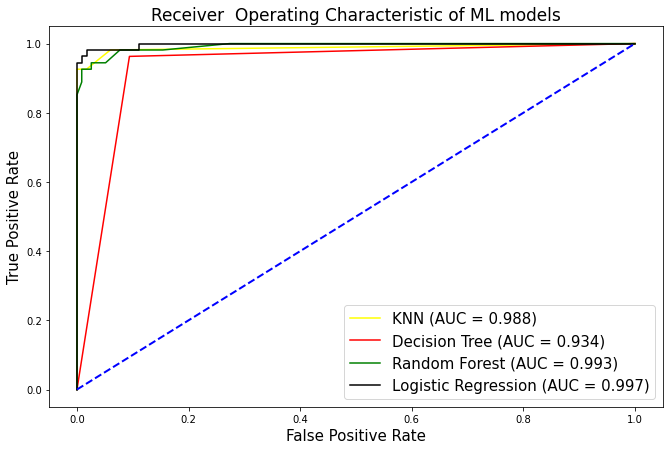

In [14]:
plt.figure(figsize=(11,7))
plt.plot(fpr, tpr, linestyle="-", color="yellow", label=f"KNN (AUC = {round(score,3)})")
plt.plot(fpr_tree, tpr_tree, linestyle="-", color="red", label=f"Decision Tree (AUC = {round(score_tree,3)})")
plt.plot(fpr_rf, tpr_rf, linestyle="-", color="green", label=f"Random Forest (AUC = {round(score_rf,3)})")
plt.plot(fpr_lg, tpr_lg, linestyle="-", color="black", label=f"Logistic Regression (AUC = {round(score_lg,3)})")
plt.plot([0, 1], [0, 1], color="blue", lw=2, linestyle="--")
plt.title("Receiver  Operating Characteristic of ML models", size=17)
plt.xlabel("False Positive Rate",fontsize='15')
plt.ylabel("True Positive Rate",fontsize='15')
plt.legend(loc="best",prop={'size': 15})
#plt.savefig('ROC_MLB.jpg', format='jpg', dpi=1000) 
plt.show()

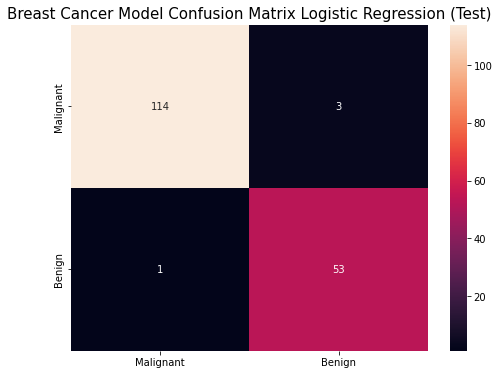

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

prediction_log_reg = log_reg.predict(X_test)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, prediction_log_reg), annot=True, fmt="d",
           yticklabels=['Malignant','Benign'], xticklabels=['Malignant','Benign'])
plt.title("Breast Cancer Model Confusion Matrix Logistic Regression (Test)", size=15)
#plt.savefig('BRC_CM_Test.jpg', format='jpg', dpi=1000) 
plt.show()

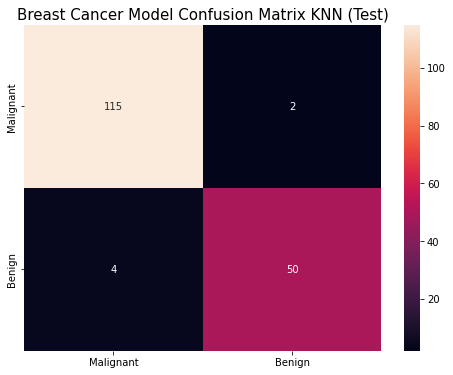

In [16]:
prediction_knn = knn.predict(X_test)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, prediction_knn), annot=True, fmt="d",
           yticklabels=['Malignant','Benign'], xticklabels=['Malignant','Benign'])
plt.title("Breast Cancer Model Confusion Matrix KNN (Test)", size=15)
#plt.savefig('BRC_CM_Test.jpg', format='jpg', dpi=1000) 
plt.show()

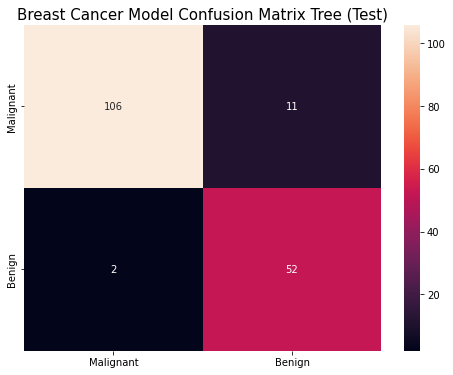

In [17]:
prediction_tree = tree.predict(X_test)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, prediction_tree), annot=True, fmt="d",
           yticklabels=['Malignant','Benign'], xticklabels=['Malignant','Benign'])
plt.title("Breast Cancer Model Confusion Matrix Tree (Test)", size=15)
#plt.savefig('BRC_CM_Test.jpg', format='jpg', dpi=1000) 
plt.show()

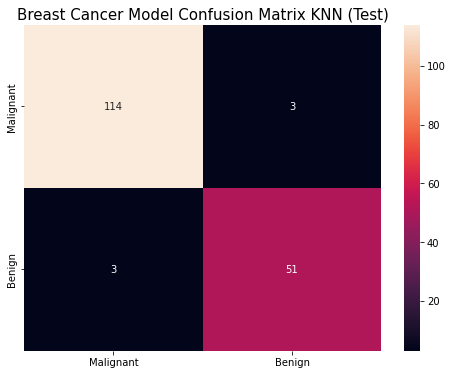

In [18]:
prediction_rf = rf.predict(X_test)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, prediction_rf), annot=True, fmt="d",
           yticklabels=['Malignant','Benign'], xticklabels=['Malignant','Benign'])
plt.title("Breast Cancer Model Confusion Matrix KNN (Test)", size=15)
#plt.savefig('BRC_CM_Test.jpg', format='jpg', dpi=1000) 
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, classification_report

print('LG Accuracy = ', accuracy_score(y_test, prediction_log_reg) *100, '%')
print(classification_report(y_test, prediction_log_reg))

print('KNN Accuracy = ', accuracy_score(y_test, prediction_knn) *100, '%')
print(classification_report(y_test, prediction_knn))

print('DR Accuracy = ', accuracy_score(y_test, prediction_tree) *100, '%')
print(classification_report(y_test, prediction_tree))

print('RF Accuracy = ', accuracy_score(y_test, prediction_rf) *100, '%')
print(classification_report(y_test, prediction_rf))

LG Accuracy =  97.6608187134503 %
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       117
           1       0.95      0.98      0.96        54

    accuracy                           0.98       171
   macro avg       0.97      0.98      0.97       171
weighted avg       0.98      0.98      0.98       171

KNN Accuracy =  96.49122807017544 %
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       117
           1       0.96      0.93      0.94        54

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

DR Accuracy =  92.39766081871345 %
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       117
           1       0.83      0.96      0.89        54

    accuracy                           0.92       171
   macro avg       0.90